(1280, 960, 3) (1044, 788, 3) (1280, 960, 3)


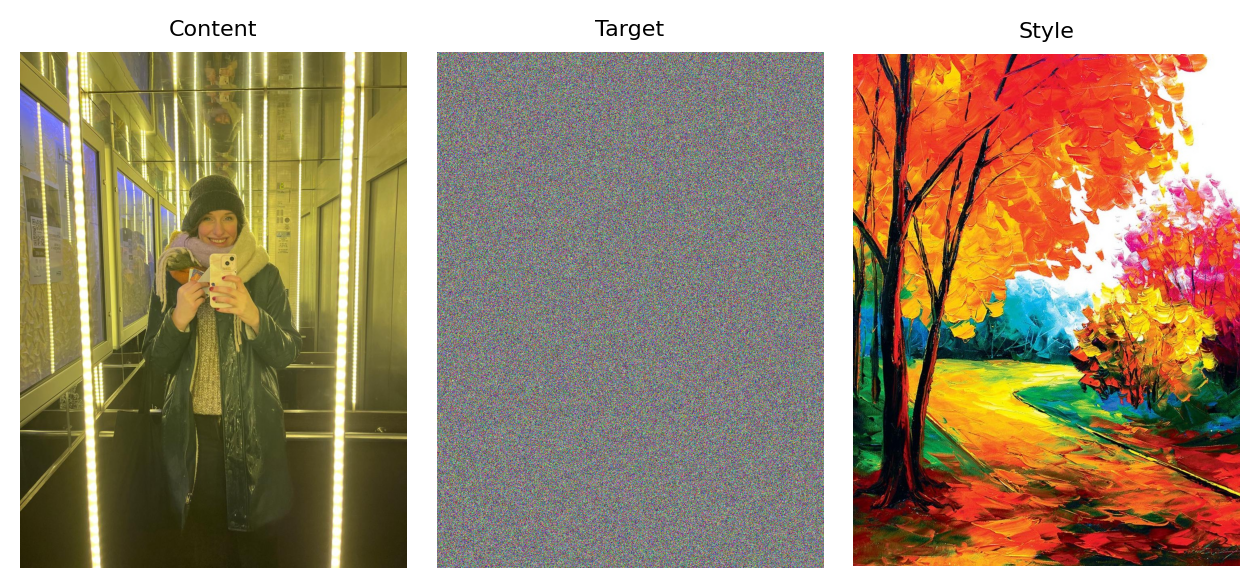

torch.Size([1, 3, 341, 256]) torch.Size([1, 3, 339, 256]) torch.Size([1, 3, 341, 256])


/usr/local/lib/python3.10/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T

from imageio import imread
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

plot_bool = True
mj_img = True
device = "cuda" if torch.cuda.is_available() else "cpu"

vgg_net = torchvision.models.vgg19(weights='IMAGENET1K_V1')

for p in vgg_net.parameters():
    p.requires_grad = False

vgg_net.eval()

if mj_img:
    # img_style = Image.open("/content/style_mj.jpeg")
    img_style = Image.open("/content/style_mj3.jpg")
    # img_content = Image.open("/content/content_pep1.jpeg")
    img_content = Image.open("/content/content_mj1.jpeg")
    # img_content = Image.open("/content/content_mj2.jpeg")
    img_style = np.asarray(img_style)
    img_content = np.asarray(img_content)
else:
    img_content = imread("https://upload.wikimedia.org/wikipedia/commons/thumb/6/61/De_nieuwe_vleugel_van_het_Stedelijk_Museum_Amsterdam.jpg/1920px-De_nieuwe_vleugel_van_het_Stedelijk_Museum_Amsterdam.jpg")
    img_style = imread("https://upload.wikimedia.org/wikipedia/commons/thumb/c/c5/Edvard_Munch%2C_1893%2C_The_Scream%2C_oil%2C_tempera_and_pastel_on_cardboard%2C_91_x_73_cm%2C_National_Gallery_of_Norway.jpg/220px-Edvard_Munch%2C_1893%2C_The_Scream%2C_oil%2C_tempera_and_pastel_on_cardboard%2C_91_x_73_cm%2C_National_Gallery_of_Norway.jpg")

img_target = np.random.randint(low=0, high=255, size=img_content.shape, dtype=np.uint8)

print(img_content.shape, img_style.shape, img_target.shape)

Transforms = T.Compose([
    T.ToTensor(),
    T.Resize(256),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

if plot_bool:
    fig, ax = plt.subplots(1, 3, dpi=200, tight_layout=True)
    for i, img in enumerate((img_content, img_target, img_style)):
        ax[i].imshow(img)
        ax[i].axis('off')
    ax[0].set_title('Content', fontsize=8)
    ax[1].set_title('Target', fontsize=8)
    ax[2].set_title('Style', fontsize=8)
    plt.show()

img_content = Transforms(img_content).unsqueeze(0)
img_style = Transforms(img_style).unsqueeze(0)
img_target = Transforms(img_target).unsqueeze(0)

print(img_content.shape, img_style.shape, img_target.shape)


Feature map ConvLayer_0 is size torch.Size([1, 64, 341, 256])
Feature map ConvLayer_1 is size torch.Size([1, 64, 341, 256])
Feature map ConvLayer_2 is size torch.Size([1, 128, 170, 128])
Feature map ConvLayer_3 is size torch.Size([1, 128, 170, 128])
Feature map ConvLayer_4 is size torch.Size([1, 256, 85, 64])
Feature map ConvLayer_5 is size torch.Size([1, 256, 85, 64])
Feature map ConvLayer_6 is size torch.Size([1, 256, 85, 64])
Feature map ConvLayer_7 is size torch.Size([1, 256, 85, 64])
Feature map ConvLayer_8 is size torch.Size([1, 512, 42, 32])
Feature map ConvLayer_9 is size torch.Size([1, 512, 42, 32])
Feature map ConvLayer_10 is size torch.Size([1, 512, 42, 32])
Feature map ConvLayer_11 is size torch.Size([1, 512, 42, 32])
Feature map ConvLayer_12 is size torch.Size([1, 512, 21, 16])
Feature map ConvLayer_13 is size torch.Size([1, 512, 21, 16])
Feature map ConvLayer_14 is size torch.Size([1, 512, 21, 16])
Feature map ConvLayer_15 is size torch.Size([1, 512, 21, 16])


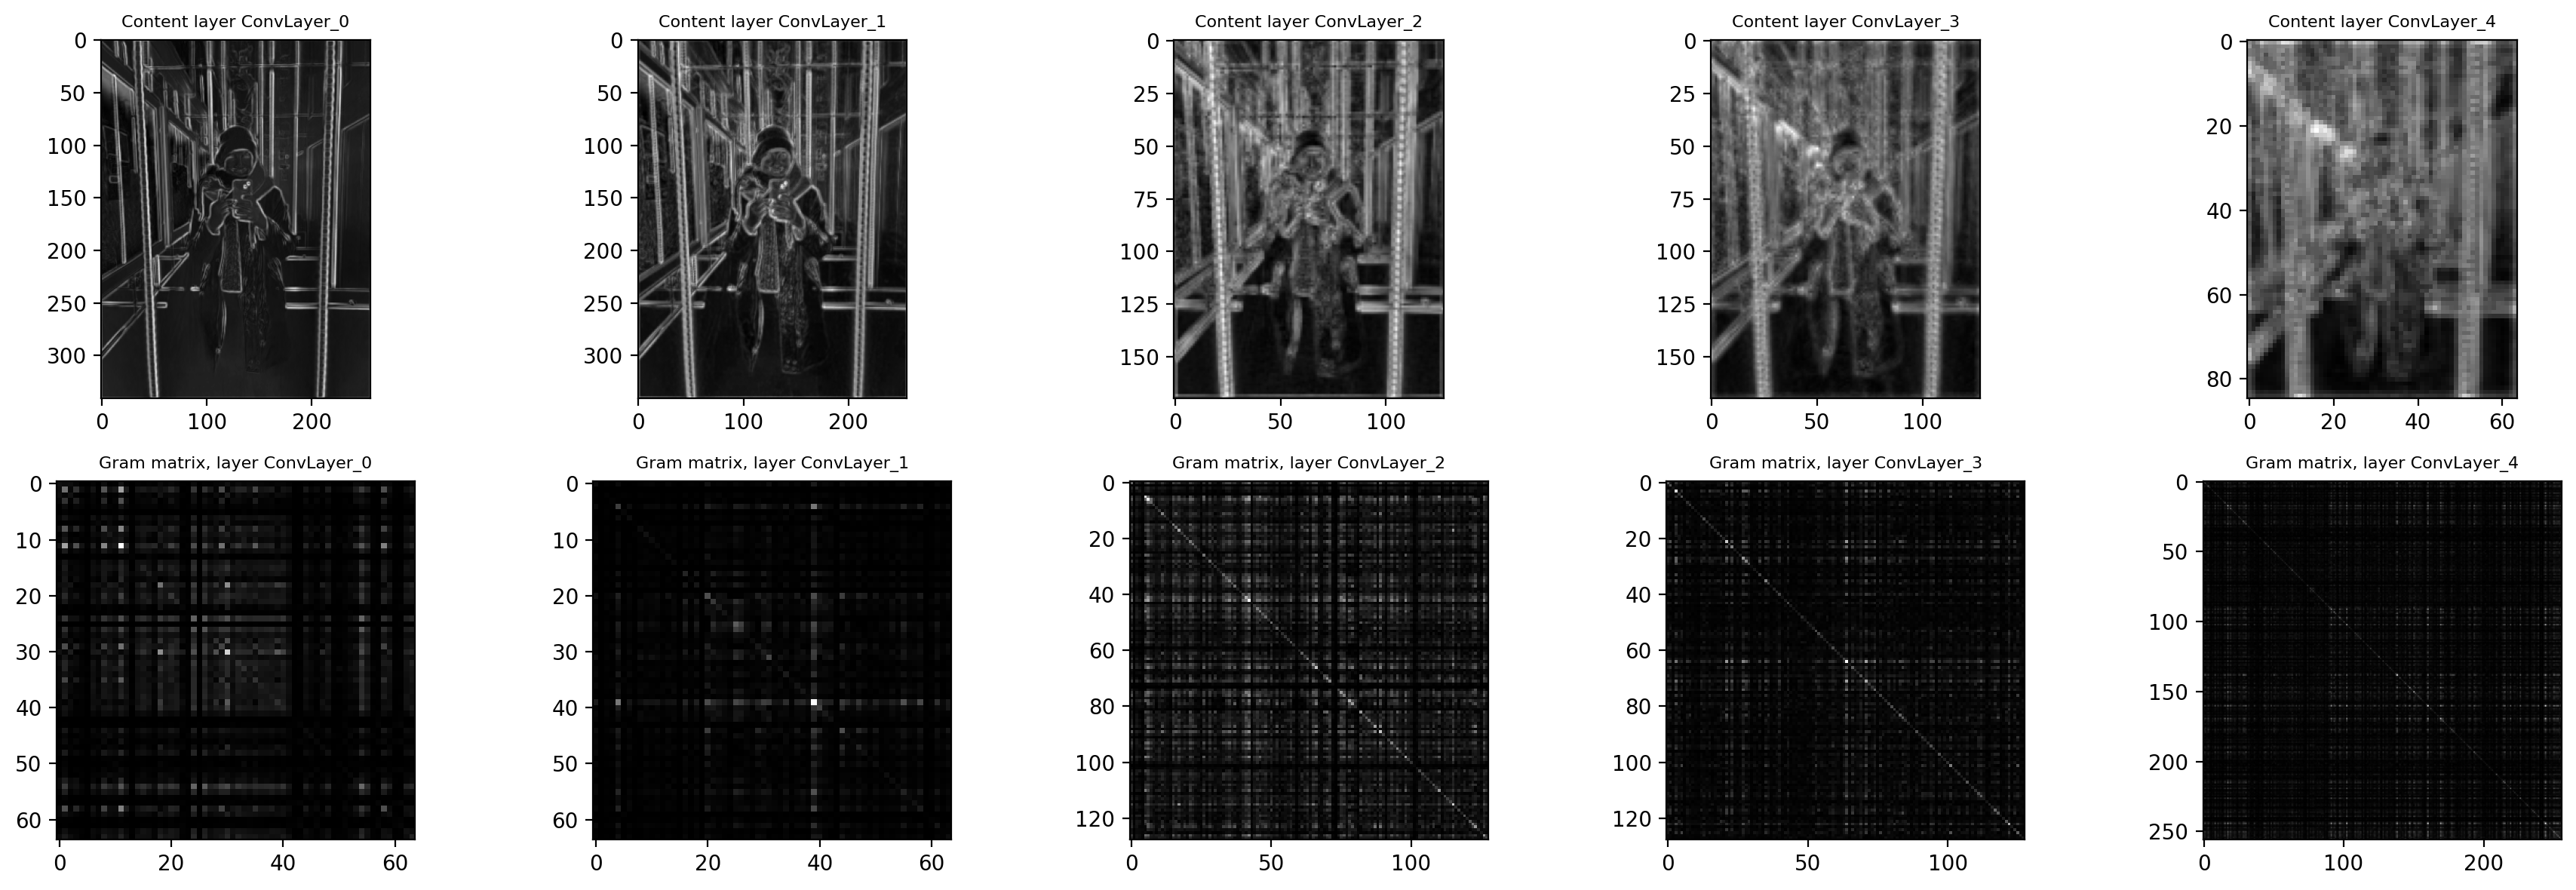

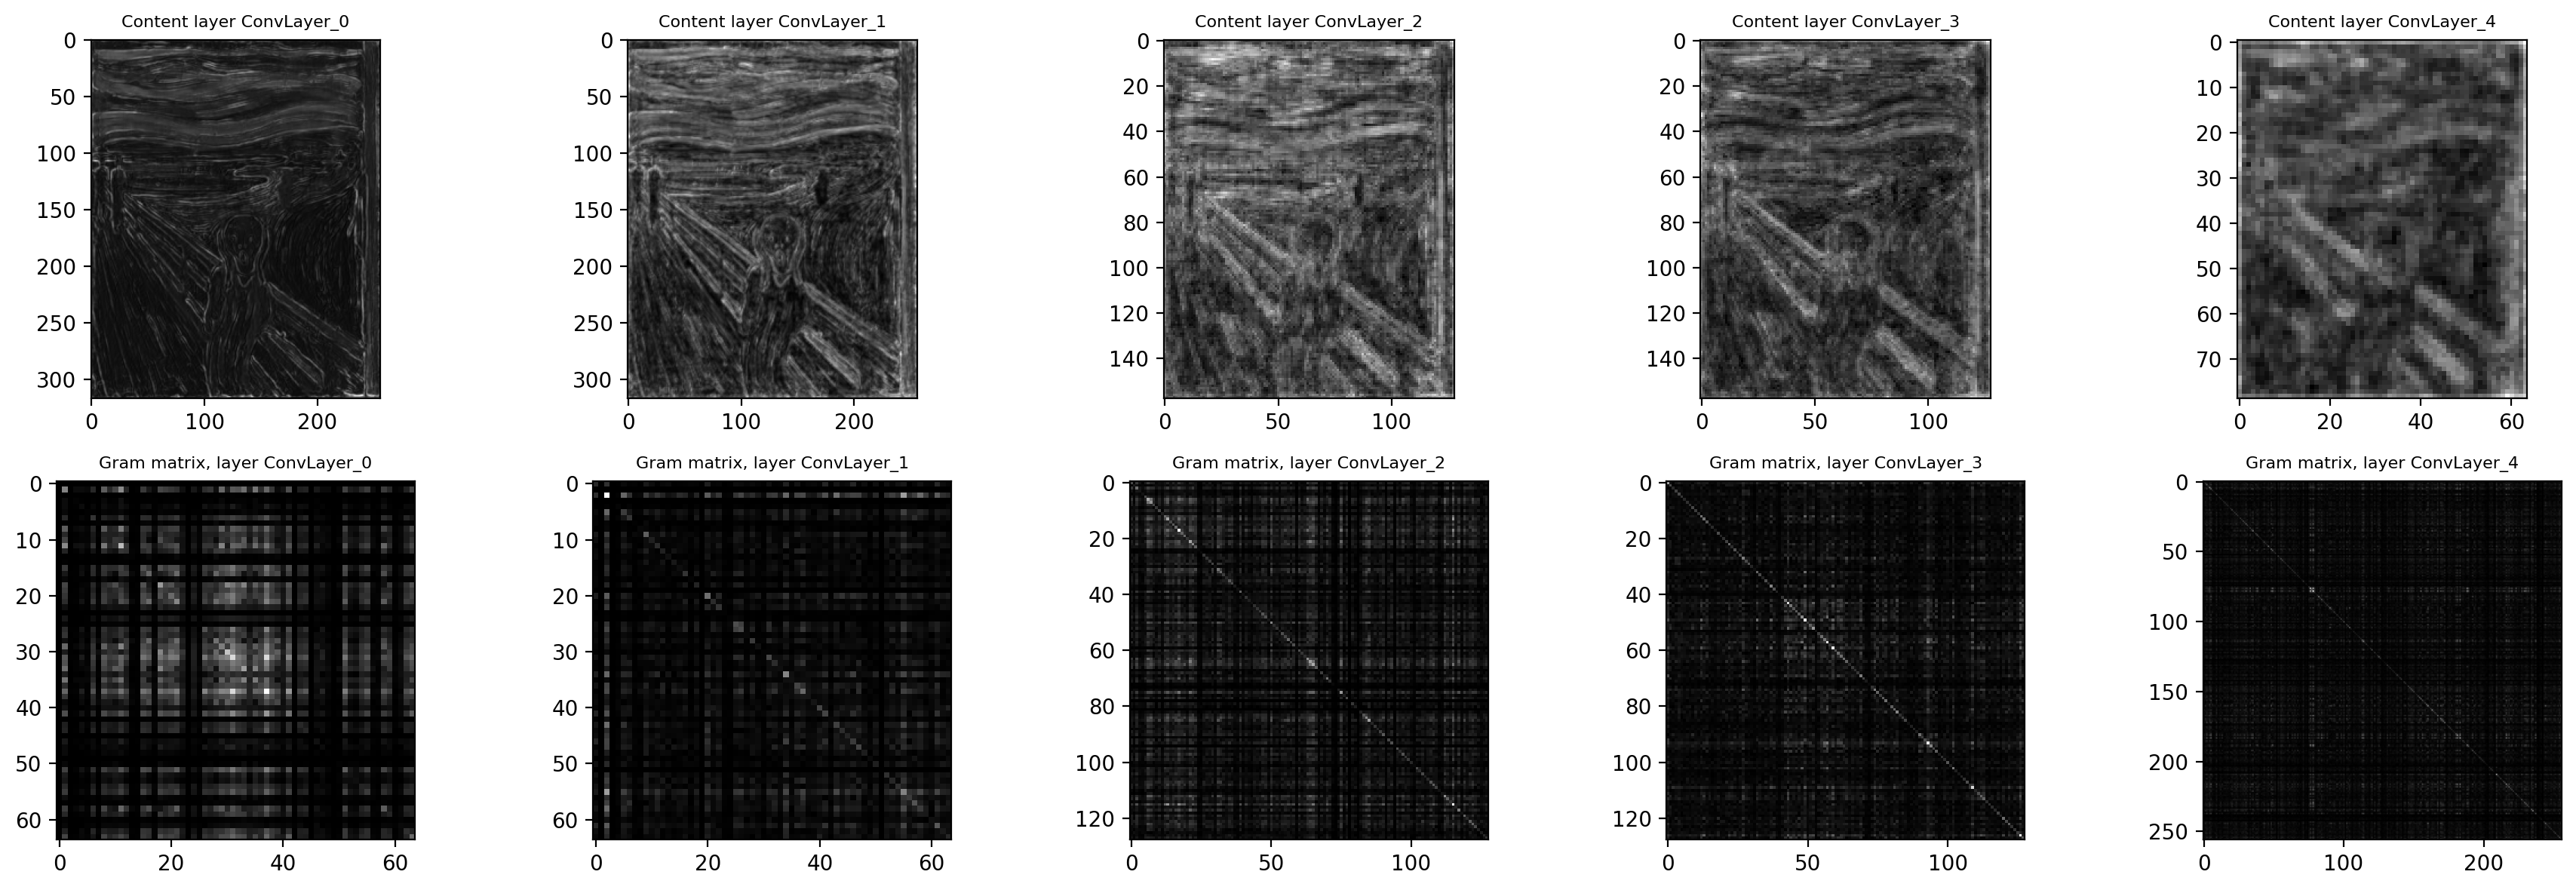

In [ ]:
# functions
def getFeatureMapActs(img, net):
    feat_maps = []
    feat_names = []

    layer_idx = 0

    for layer in net.features:
        img = layer(img)
        if 'Conv2d' in str(layer):
            feat_maps.append(img)
            feat_names.append("ConvLayer_" + str(layer_idx))
            layer_idx += 1
    return feat_maps, feat_names


def gram_mat(M):
    _, channels, height, width = M.shape
    M = M.reshape(channels, height * width)
    gram = torch.mm(M, M.t()) / (channels * height * width)
    return gram


# some info
feat_maps, feat_names = getFeatureMapActs(img_content, vgg_net)

for i in range(len(feat_names)):
    print(f"Feature map {feat_names[i]} is size {feat_maps[i].shape}")

content_feat_maps, content_feat_names = getFeatureMapActs(img_content, vgg_net)
style_feat_maps, style_feat_names = getFeatureMapActs(img_style, vgg_net)

# show features maps and gam matrices of content and style maps
if plot_bool:
    # content maps
    fig, ax = plt.subplots(2, 5, figsize=(18,6), dpi=200, tight_layout=True)
    for i in range(5):
        pic = np.mean(content_feat_maps[i].squeeze().numpy(), axis=0)
        pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic))
        ax[0, i].imshow(pic, cmap='gray')
        ax[0, i].set_title("Content layer " + str(content_feat_names[i]), fontsize=8)

        pic = gram_mat(content_feat_maps[i]).numpy()
        pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic))
        ax[1, i].imshow(pic, cmap="gray")
        ax[1, i].set_title("Gram matrix, layer " + str(content_feat_names[i]), fontsize=8)
    plt.show()
    # style maps
    fig, ax = plt.subplots(2, 5, figsize=(18, 6), dpi=200, tight_layout=True)
    for i in range(5):
        pic = np.mean(style_feat_maps[i].squeeze().numpy(), axis=0)
        pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic))
        ax[0, i].imshow(pic, cmap='gray')
        ax[0, i].set_title("Content layer " + str(style_feat_names[i]), fontsize=8)

        pic = gram_mat(style_feat_maps[i]).numpy()
        pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic))
        ax[1, i].imshow(pic, cmap="gray")
        ax[1, i].set_title("Gram matrix, layer " + str(style_feat_names[i]), fontsize=8)
    plt.show()

In [ ]:
# Style transfer
content_layers = [
    "ConvLayer_0",
   # "ConvLayer_1",
   # "ConvLayer_2",
    "ConvLayer_4"
    ]
style_layers = [
    "ConvLayer_1",
    "ConvLayer_2",
    "ConvLayer_3",
    "ConvLayer_4",
    "ConvLayer_5"
    ]
style_layer_weights = [1, 0.5, 0.5, 0.2, 0.1]

style_scaling = 1e5
# style_scaling = 1e6

n_epochs = 1500

vgg_net.to(device)

img_content = img_content.to(device)
img_style = img_style.to(device)
target = img_target.clone().to(device)
target.requires_grad = True

optimizer = torch.optim.RMSprop([target], lr=5e-3)

content_feat_maps, content_feat_names = getFeatureMapActs(img_content, vgg_net)
style_feat_maps, style_feat_names = getFeatureMapActs(img_style, vgg_net)

for epoch in range(n_epochs):
    target_feat_maps, target_feat_names = getFeatureMapActs(target, vgg_net)
    style_loss = 0
    content_loss = 0

    for layer_i in range(len(target_feat_maps)):

        if target_feat_names[layer_i] in content_layers:
            content_loss += torch.mean((target_feat_maps[layer_i] - content_feat_maps[layer_i]) ** 2)

        if target_feat_names[layer_i] in style_layers:
            G_target = gram_mat(target_feat_maps[layer_i])
            G_style = gram_mat(style_feat_maps[layer_i])

            style_loss += torch.mean((G_target - G_style) ** 2) * style_layer_weights[
                style_layers.index(target_feat_names[layer_i])]

    loss = content_loss + style_scaling * style_loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4} loss: {loss.item():.4f}")

Epoch    0 loss: 127.7225
Epoch   50 loss: 59.2917
Epoch  100 loss: 48.6728
Epoch  150 loss: 41.9057
Epoch  200 loss: 36.1146
Epoch  250 loss: 30.5376
Epoch  300 loss: 24.9035
Epoch  350 loss: 19.8412
Epoch  400 loss: 16.2267
Epoch  450 loss: 14.0404
Epoch  500 loss: 12.6800
Epoch  550 loss: 11.7291
Epoch  600 loss: 11.0164
Epoch  650 loss: 10.4604
Epoch  700 loss: 10.0258
Epoch  750 loss: 9.6719
Epoch  800 loss: 9.3729
Epoch  850 loss: 9.1282
Epoch  900 loss: 8.9190
Epoch  950 loss: 8.7475
Epoch 1000 loss: 8.6072
Epoch 1050 loss: 8.4663
Epoch 1100 loss: 8.3549
Epoch 1150 loss: 8.2660
Epoch 1200 loss: 8.2005
Epoch 1250 loss: 8.1221
Epoch 1300 loss: 8.0599
Epoch 1350 loss: 7.9975
Epoch 1400 loss: 7.9379
Epoch 1450 loss: 7.8892


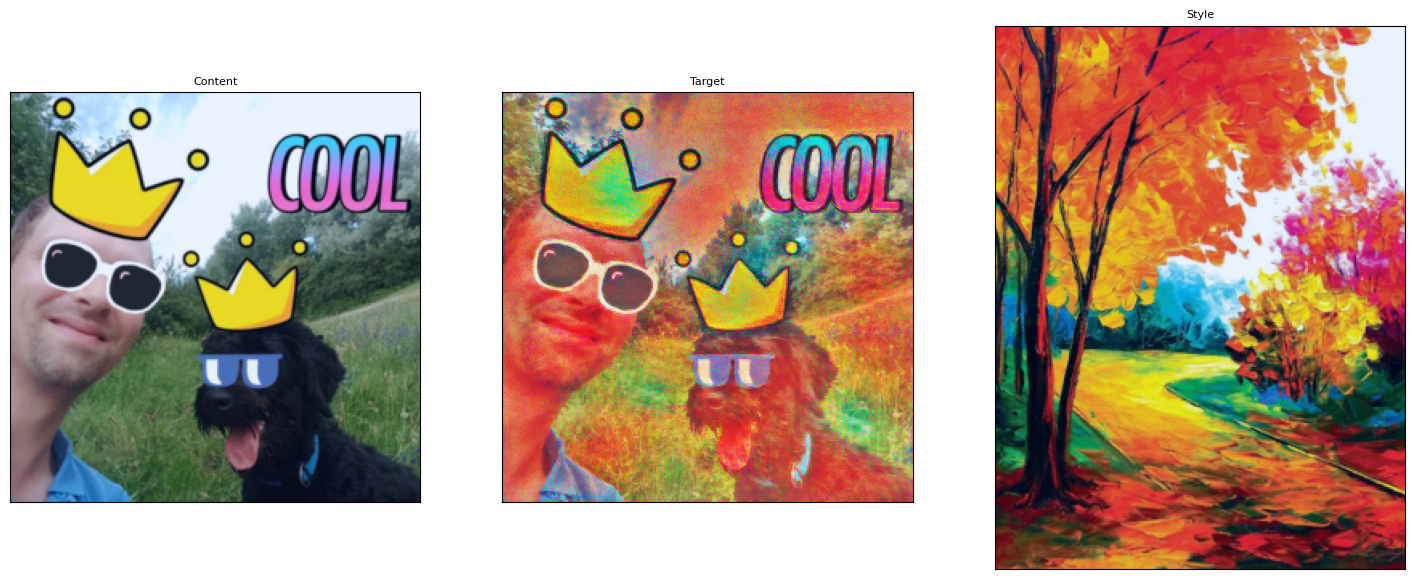

In [ ]:
#%% Show the result
fig, ax = plt.subplots(1, 3, figsize=(18, 11))
pic = img_content.cpu().squeeze().numpy().transpose(1, 2, 0)
pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic))
ax[0].imshow(pic)
ax[0].set_title("Content", fontsize=8)
ax[0].set_xticks([])
ax[0].set_yticks([])

pic = torch.sigmoid(target).cpu().detach().squeeze().numpy().transpose(1, 2, 0)
ax[1].imshow(pic)
ax[1].set_title('Target', fontsize=8)
ax[1].set_xticks([])
ax[1].set_yticks([])

pic = img_style.cpu().squeeze().numpy().transpose(1, 2, 0)
pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic))
ax[2].imshow(pic)
ax[2].set_title('Style', fontsize=8)
ax[2].set_xticks([])
ax[2].set_yticks([])

plt.show()